In [35]:
# importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Load the csv dataset into a DataFrame
data =pd.read_csv('/content/loan_approval_dataset.csv')

In [52]:
# Display first 5 rows of dataset
data.head()

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1


In [8]:
# Shows column names,datatypes and Null values
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4269 entries, 0 to 4268
Data columns (total 13 columns):
 #   Column                     Non-Null Count  Dtype 
---  ------                     --------------  ----- 
 0   loan_id                    4269 non-null   int64 
 1    no_of_dependents          4269 non-null   int64 
 2    education                 4269 non-null   object
 3    self_employed             4269 non-null   object
 4    income_annum              4269 non-null   int64 
 5    loan_amount               4269 non-null   int64 
 6    loan_term                 4269 non-null   int64 
 7    cibil_score               4269 non-null   int64 
 8    residential_assets_value  4269 non-null   int64 
 9    commercial_assets_value   4269 non-null   int64 
 10   luxury_assets_value       4269 non-null   int64 
 11   bank_asset_value          4269 non-null   int64 
 12   loan_status               4269 non-null   object
dtypes: int64(10), object(3)
memory usage: 433.7+ KB


In [9]:
# Remove extra spaces from column names
data.columns=data.columns.str.strip()

In [41]:
# Check missing values in each column
data.isnull().sum()
data

,no_of_dependents,education,self_employed,income_annum,loan_amount,loan_term,cibil_score,residential_assets_value,commercial_assets_value,luxury_assets_value,bank_asset_value,loan_status
0,2,0,0,9600000,29900000,12,778,2400000,17600000,22700000,8000000,0
1,0,1,1,4100000,12200000,8,417,2700000,2200000,8800000,3300000,1
2,3,0,0,9100000,29700000,20,506,7100000,4500000,33300000,12800000,1
3,3,0,0,8200000,30700000,8,467,18200000,3300000,23300000,7900000,1
4,5,1,1,9800000,24200000,20,382,12400000,8200000,29400000,5000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...
4264,5,0,1,1000000,2300000,12,317,2800000,500000,3300000,800000,1
4265,0,1,1,3300000,11300000,20,559,4200000,2900000,11000000,1900000,0
4266,2,1,0,6500000,23900000,18,457,1200000,12400000,18100000,7300000,1
4267,1,1,0,4100000,12800000,8,780,8200000,700000,14100000,5800000,0


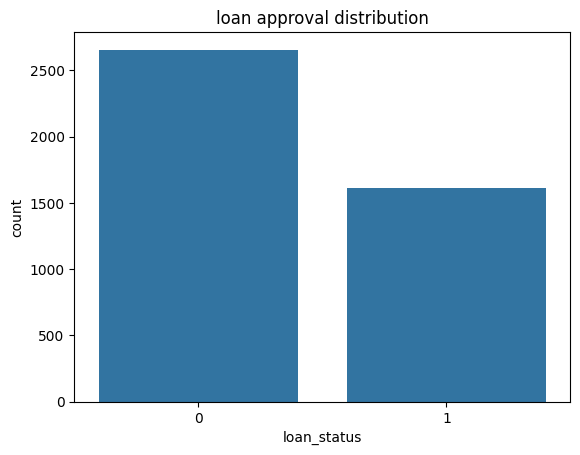

In [37]:
#  Visualize loan approval distribution
sns.countplot(x='loan_status',data=data)
plt.title('loan approval distribution')
plt.show()

<Axes: >

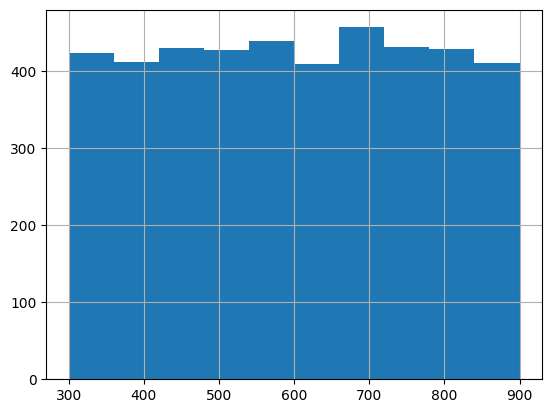

In [38]:
# Plot histogram of CIBIL score
data['cibil_score'].hist()

<Axes: >

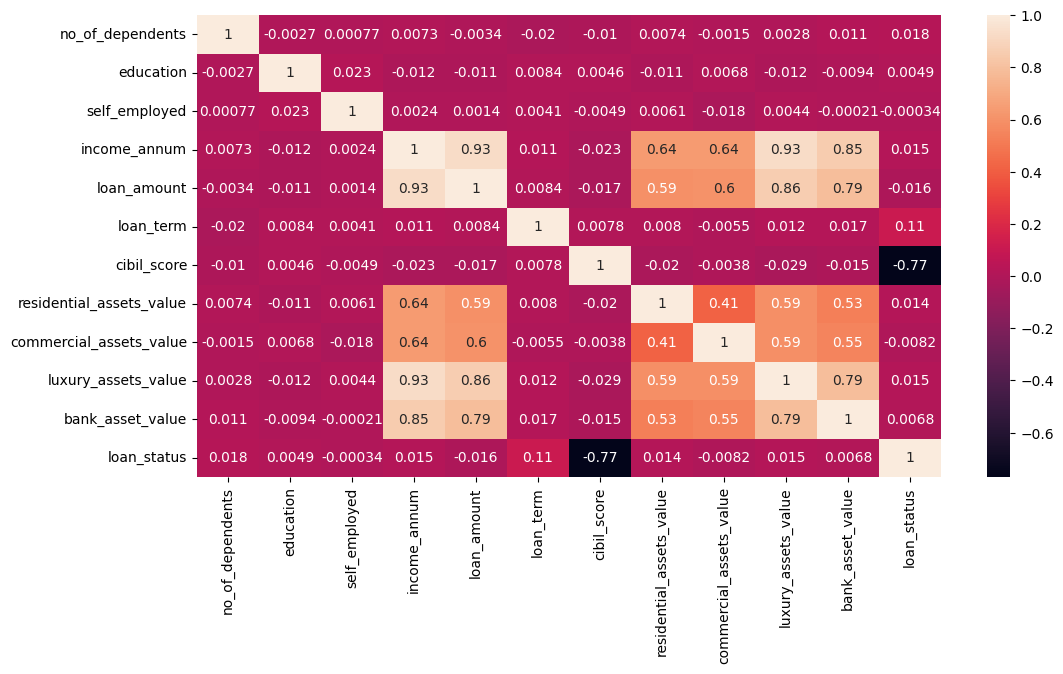

In [47]:
# Create correlation heatmap
plt.figure(figsize=(12,6))
sns.heatmap(data.corr(),annot=True)

In [12]:
# Import LabelEncoder to convert text labels into numerical values
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()
# Convert categorical columns into numerical format
data['education'] = le.fit_transform(data['education'])
data['self_employed'] = le.fit_transform(data['self_employed'])
data['loan_status'] = le.fit_transform(data['loan_status'])

In [13]:
# Store all input features in X
# axis=1 means column operation
X=data.drop('loan_status',axis=1)

In [14]:
# Store target variable in y
y=data['loan_status']

In [15]:
# Import train_test_split function
from sklearn.model_selection import train_test_split
# Split dataset into training and testing sets
# 80% data for training and 20% for testing
# random_state ensures reproducible results
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [16]:
# Import Logistic Regression algorithm
from sklearn.linear_model import LogisticRegression
model=LogisticRegression()
model.fit(x_train,y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression()

In [17]:
# Predict loan approval using testing data
y_pred =model.predict(x_test)

In [18]:
# Import accuracy metric and calculate prediction
from sklearn.metrics import accuracy_score
print(accuracy_score(y_test,y_pred))

0.6323185011709602


In [20]:
# Import Decision Tree Classifier
from sklearn.tree import DecisionTreeClassifier
model=DecisionTreeClassifier(random_state=42)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(accuracy_score(y_test,y_pred))

0.9754098360655737


In [22]:
# Print training and testing accuracy
# Helps detect overfitting
print('Training accuracy',model.score(x_train,y_train))
print('Testing accuracy',model.score(x_test,y_test))

Training accuracy 1.0
Testing accuracy 0.9754098360655737


In [53]:
# Limit tree depth to reduce overfitting
model=DecisionTreeClassifier(max_depth=5)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)


In [54]:
# Evaluate tuned model
print('Training accuracy',model.score(x_train,y_train))
print('Testing accuracy',model.score(x_test,y_test))

Training accuracy 0.9756954612005857
Testing accuracy 0.9695550351288056


In [26]:
# Import Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
model=RandomForestClassifier(random_state=42)
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(accuracy_score(y_test,y_pred))

0.9789227166276346


In [55]:
# Print training and testing accuracy
print('Training data',model.score(x_train,y_train))
print('Testing data',model.score(x_test,y_test))

Training data 0.9756954612005857
Testing data 0.9695550351288056


In [30]:
# Finding important feature
importance = pd.DataFrame({'Feature':X.columns,'Importance':model.feature_importances_})
print(importance.sort_values(by='Importance',ascending=False))

                     Feature  Importance
7                cibil_score    0.799849
6                  loan_term    0.060263
5                loan_amount    0.027441
10       luxury_assets_value    0.018540
0                    loan_id    0.017000
4               income_annum    0.016970
8   residential_assets_value    0.016802
9    commercial_assets_value    0.015347
11          bank_asset_value    0.014443
1           no_of_dependents    0.008008
3              self_employed    0.002940
2                  education    0.002397


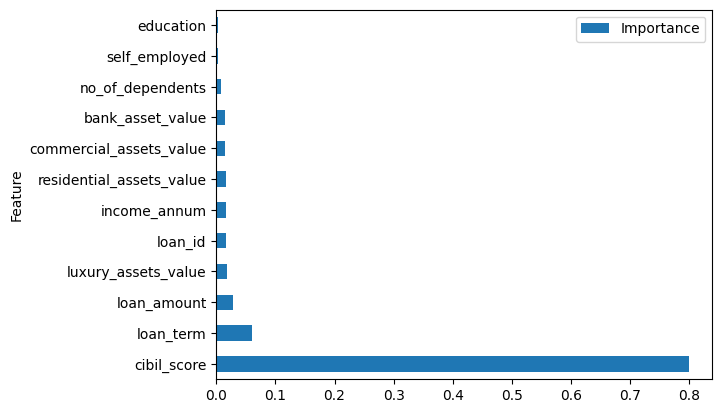

In [49]:
# Feature importance visualization
importance.sort_values(by='Importance',ascending=False).plot(kind='barh',x='Feature',y='Importance')
plt.show()

In [32]:
# Remove loan_id column because it is only an identifier
data=data.drop('loan_id',axis=1)

In [44]:
# Retrain the model
X=data.drop('loan_status',axis=1)
y=data['loan_status']
x_train,x_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [45]:
model=RandomForestClassifier()
model.fit(x_train,y_train)
y_pred=model.predict(x_test)
print(accuracy_score(y_test,y_pred))

0.977751756440281


In [46]:
print('Training data',model.score(x_train,y_train))
print('Testing data',model.score(x_test,y_test))

Training data 1.0
Testing data 0.977751756440281


In [50]:
# Import classification report
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       536
           1       0.98      0.96      0.97       318

    accuracy                           0.98       854
   macro avg       0.98      0.97      0.98       854
weighted avg       0.98      0.98      0.98       854



In [51]:
# Import confusion matrix
from sklearn.metrics import confusion_matrix
print(confusion_matrix(y_test,y_pred))

[[531   5]
 [ 14 304]]


In [ ]:
# Random Forest achieved the best performance with approximately 97% testing accuracy.
# Feature importance analysis showed that CIBIL score was the most influential factor affecting loan approval.
# The project successfully demonstrated the complete machine learning workflow including data cleaning, EDA, model training, evaluation, and feature analysis.